In [5]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Fungerar om notebooken körs från projektroten eller din undermapp.
projekt = Path.cwd()
if not (projekt / "CSV-files").is_dir():
    projekt = projekt.parent

data = projekt / "CSV-files"
assert data.is_dir(), "Kunde inte hitta CSV-files."

In [6]:
fruktsamhet = pd.read_csv(
    data / "FertilitetPerKommun.csv",
    sep=";",
    na_values=[".."]
)

konjunktur = pd.read_csv(
    data / "konjunkturklockan.csv",
    sep=";",
    na_values=[".."]
)

tathet = pd.read_csv(
    data / "befolkningstathet.csv",
    encoding="cp1252",
    na_values=[".."]
)

In [7]:
display(fruktsamhet.head())
display(konjunktur.head())
display(tathet.head())

print("Fruktsamhet:", fruktsamhet.shape)
print("Konjunktur:", konjunktur.shape)
print("Befolkningstäthet:", tathet.shape)

,region,kön,tabellinnehåll,år,Värde
0,Upplands Väsby,män,Antal,2000,1.43
1,Upplands Väsby,män,Antal,2001,1.52
2,Upplands Väsby,män,Antal,2002,1.51
3,Upplands Väsby,män,Antal,2003,1.64
4,Upplands Väsby,män,Antal,2004,1.56


,indikator,tabellinnehåll,månad,Värde
0,BNP-indikator månad,Konjunkturläge,2000M01,-1.07
1,BNP-indikator månad,Konjunkturläge,2000M02,-0.84
2,BNP-indikator månad,Konjunkturläge,2000M03,-0.59
3,BNP-indikator månad,Konjunkturläge,2000M04,-0.29
4,BNP-indikator månad,Konjunkturläge,2000M05,0.01


,ï»¿Kommunkod,Kommun,Kon,Ã…r,BefolkningstÃ¤thet (invÃ¥nare per kvkm),FolkmÃ¤ngd
0,114,Upplands VÃ¤sby,1+2,2000,498.6,37576.0
1,114,Upplands VÃ¤sby,1+2,2001,497.9,37524.0
2,114,Upplands VÃ¤sby,1+2,2002,496.8,37444.0
3,114,Upplands VÃ¤sby,1+2,2003,496.2,37397.0
4,114,Upplands VÃ¤sby,1+2,2004,497.8,37517.0


Fruktsamhet: (15080, 5)
Konjunktur: (8960, 4)
Befolkningstäthet: (7540, 6)


In [8]:
fruktsamhet = fruktsamhet.loc[
    fruktsamhet["kön"] == "kvinnor"
].copy()

fruktsamhet["Värde"] = pd.to_numeric(
    fruktsamhet["Värde"], errors="raise"
)

print("Antal kommuner:", fruktsamhet["region"].nunique())
print("Antal rader:", len(fruktsamhet))
print("Saknade värden:", fruktsamhet["Värde"].isna().sum())

assert not fruktsamhet.duplicated(["region", "år"]).any()

Antal kommuner: 290
Antal rader: 7540
Saknade värden: 204


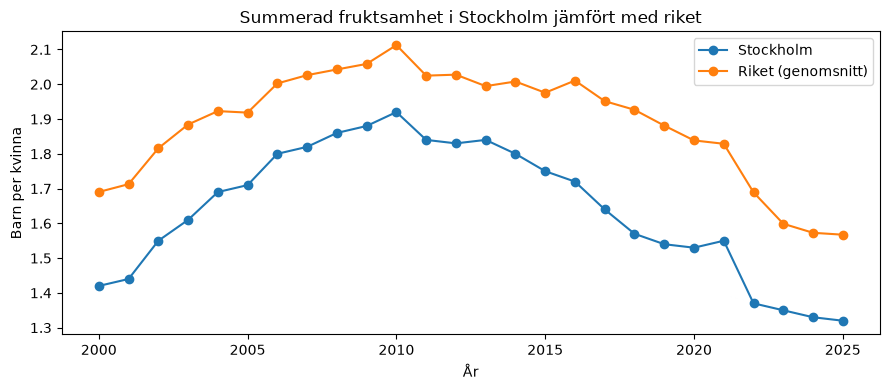

In [10]:
kommun = "Stockholm"


urval = (
    fruktsamhet.loc[fruktsamhet["region"] == kommun]
    .sort_values("år")
)

riket = (
    fruktsamhet.groupby("år")["Värde"].mean()
    .reset_index()
    .sort_values("år")
)

ax = urval.plot(
    x="år",
    y="Värde",
    marker="o",
    label=kommun,
    figsize=(9, 4)
)

riket.plot(
    x="år",
    y="Värde",
    marker="o",
    label="Riket (genomsnitt)",
    ax=ax
)

ax.set_title(f"Summerad fruktsamhet i {kommun} jämfört med riket")
ax.set_ylabel("Barn per kvinna")
ax.set_xlabel("År")
ax.legend()
plt.tight_layout()
plt.show()